# Archelec — Topic Modeling sur l'extrême droite (1981–1988–1993)

## Contexte de recherche

Ce notebook analyse les **professions de foi** (PF) des candidats d'extrême droite aux élections législatives françaises de **1978 à 1993**, issues du corpus Archelec (CEVIPOF / Sciences Po).

---
## Étape 0 — Imports et configuration

In [1]:
import os, re, unicodedata, textwrap
from pathlib import Path
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick

# ── Chemin racine du projet ───────────────────────────────────────────────────
PROJECT_ROOT   = Path('.')
TEXT_FILES_DIR = PROJECT_ROOT / 'data' / 'text_files'
YEARS          = [1978, 1981, 1988, 1993]

# Affichage de l'arborescence et du nombre de fichiers
print(f"Racine du projet : {PROJECT_ROOT.resolve()}")
for year in YEARS:
    p = TEXT_FILES_DIR / str(year) / 'legislatives'
    if p.exists():
        n = len(list(p.glob('*.txt')))
        print(f"  {year}/legislatives/ → {n} fichiers .txt")
    else:
        print(f"  année {p} introuvable !")

Racine du projet : C:\Users\jonas\OneDrive - GENES\Documents\0 ENSAE\3A\S2\ML_for_NLP\NLP_project
  1978/legislatives/ → 5030 fichiers .txt
  1981/legislatives/ → 3182 fichiers .txt
  1988/legislatives/ → 3628 fichiers .txt
  1993/legislatives/ → 5936 fichiers .txt


---
## Étape 1 — Chargement des fichiers texte et préparation des données

On charge tous les fichiers `.txt` des dossiers `legislatives/` et on pré-traite les métadonnées encodées dans le nom de fichier (département, circonscription, tour, numéro de candidat).

La fonction _parse_filename_ permet de mettre en forme correctement les méta données à partir du nom des fichiers.

La fonction _load_corpus_ charge les professions de foi uniquement. Elle appelle également la fonction _parse_filename_ pour créer les méta données.

In [2]:
def parse_filename(filepath):
    """
    Mise en forme du nom de fichier Archelec pour créer des méta données :
      EL134_L_1981_06_001_01_1_PF_01.txt
      EL134_L_1981_06_02A_01_1_PF_01.txt  ← Corse (dep alphanumérique)
      EL134_L_1981_06_013_10_1_BV_pdfmasterocr.txt  ← ignoré (pas une PF)
    """
    name  = Path(filepath).stem
    parts = name.split('_')
    
    try:
        doc_type = parts[7]   # permet d'accéder à la catégorie PF = professions de foi
        
        # Numéro de candidat : peut être 'pdfmasterocr' pour les BV mal nommés
        # → on met None, le filtre doc_type != 'PF' les éliminera de toute façon
        try:
            candidat_num = int(parts[8])
        except (ValueError, IndexError):
            candidat_num = None

        # Département : peut être '001', '02A', '02B' (Corse)
        dep_raw = parts[4]
        if dep_raw.upper() in ('02A', '2A'):
            dep = '2A'   # Corse-du-Sud
        elif dep_raw.upper() in ('02B', '2B'):
            dep = '2B'   # Haute-Corse
        else:
            dep = int(dep_raw)   # cas normal : entier

        return {
            'archelec_id'  : parts[0],
            'election_type': parts[1],
            'year'         : int(parts[2]),
            'month'        : parts[3],
            'dep'          : dep,
            'circ'         : int(parts[5]),
            'tour'         : int(parts[6]),
            'doc_type'     : doc_type,
            'candidat_num' : candidat_num,
        }

    except (IndexError, ValueError) as e:
        print(f"Parsing échoué pour '{name}' : {e}")
        return {k: None for k in
                ['archelec_id','election_type','year','month',
                 'dep','circ','tour','doc_type','candidat_num']}

def load_corpus(text_files_dir, years):
    """
    Charge les fichiers .txt dans text_files/{année}/legislatives/
    Ne conserve que les documents de type PF (Profession de Foi).
    """
    records = []
    for year in years:
        folder = Path(text_files_dir) / str(year) / 'legislatives'
        if not folder.exists():
            print(f"Dossier manquant : {folder}") ; continue

        n_pf = n_skip = 0
        for fpath in sorted(folder.glob('*.txt')):
            meta = parse_filename(fpath)

            # On ne garde que les Professions de Foi
            if meta['doc_type'] != 'PF':
                n_skip += 1 ; continue

            # Lecture avec le bon encodage
            try:
                text = fpath.read_text(encoding='utf-8')
            except UnicodeDecodeError:
                text = fpath.read_text(encoding='latin-1')

            text = text.strip()
            records.append({
                'filename'     : fpath.name,
                'archelec_id'  : meta['archelec_id'],
                'year'         : year,
                'dep'          : meta['dep'],
                'circ'         : meta['circ'],
                'tour'         : meta['tour'],
                'candidat_num' : meta['candidat_num'],
                'text'         : text,
                'text_length'  : len(text),
            })
            n_pf += 1

        print(f"{year} : {n_pf} PF chargées  ({n_skip} fichiers non-PF ignorés)")

    return pd.DataFrame(records)


# Création du corpus
df_all = load_corpus(TEXT_FILES_DIR, YEARS)

# Quelques statistiques de base
print(f"\n Corpus total : {len(df_all)} professions de foi")
print("\nLongueur des textes (caractères) :")
print(df_all.groupby('year')['text_length']
      .describe()[['min','mean','max']].round(0))

1978 : 4829 PF chargées  (201 fichiers non-PF ignorés)
1981 : 3124 PF chargées  (58 fichiers non-PF ignorés)
1988 : 3544 PF chargées  (84 fichiers non-PF ignorés)
Parsing échoué pour 'EL195_L_1993_03_75__03_1_TR_02' : invalid literal for int() with base 10: ''
1993 : 5840 PF chargées  (96 fichiers non-PF ignorés)

 Corpus total : 17337 professions de foi

Longueur des textes (caractères) :
        min    mean      max
year                        
1978  139.0  5182.0  25120.0
1981  673.0  4197.0  22128.0
1988  377.0  3507.0  15489.0
1993  168.0  4171.0  50611.0


---
## Étape 2 — Identification des professions de foi d'extrême droite

Pour identifier les professions de foi d'extrème droite on utilise les méta données (table _metadata_) disponibles en ligne que l'on lie avec le corpus. Ensuite, on filtre sur le nom des partis d'extrème droite rattachés au candidat (soit le parti auquel il est rattaché, soit le parti qui le soutient).

In [3]:
# ═══════════════════════════════════════════════════════════════════════════
# ÉTAPE 2 — Identification des PF d'extrême droite via les métadonnées
# ═══════════════════════════════════════════════════════════════════════════
#
# La table metadata contient la colonne 'titulaire-liste' avec le nom du parti.


import pandas as pd

# ── 1. Chargement de la table de métadonnées ──────────────────────────────────
# Adapter le chemin et le séparateur selon votre fichier
# (souvent un .csv ou .tsv exporté depuis la base Archelec)
META_PATH = 'data/meta_data.csv'   # ← adapter si nécessaire

df_meta = pd.read_csv(META_PATH, sep=',', encoding='utf-8', low_memory=False)

print(f"Métadonnées chargées : {len(df_meta)} lignes")
print(f"Colonnes : {list(df_meta.columns)}\n")

# Affichage d'une partie de la table
print("Aperçu des colonnes 'titulaire-liste' et 'titulaire-soutien' :")
print(df_meta[['id','titulaire-liste','titulaire-soutien']].head(5).to_string())

Métadonnées chargées : 33031 lignes
Colonnes : ['id', 'date', 'subject', 'title', 'contexte-election', 'contexte-tour', 'cote', 'departement', 'departement-nom', 'departement-insee', 'identifiant de circonscription', 'images', 'pdf', 'ocr_url', 'titulaire-nom', 'titulaire-prenom', 'titulaire-sexe', 'titulaire-age', 'titulaire-age-calcule', 'titulaire-age-tranche', 'titulaire-profession', 'titulaire-mandat-en-cours', 'titulaire-mandat-passe', 'titulaire-associations', 'titulaire-autres-statuts', 'titulaire-soutien', 'titulaire-liste', 'titulaire-decorations', 'suppleant-nom', 'suppleant-prenom', 'suppleant-sexe', 'suppleant-age', 'suppleant-age-calcule', 'suppleant-age-tranche', 'suppleant-profession', 'suppleant-mandat-en-cours', 'suppleant-mandat-passe', 'suppleant-associations', 'suppleant-autres-statuts', 'suppleant-soutien', 'suppleant-liste', 'suppleant-decorations']

Aperçu des colonnes 'titulaire-liste' et 'titulaire-soutien' :
                               id titulaire-liste  

In [4]:
# ── 2. Définition des partis et soutiens d'extrême droite ─────────────────────
ED_PARTIS = {
    # Front National et variantes
    'Front national',
    'Front National',
    'Front national pour l\'unité française',
    'Front National pour l\'Unité Française',
    'Front national de la jeunesse',
    'Front national populaire',                                                                                                                              

    # Parti des Forces Nouvelles (rival du FN en 1981, même famille)
    'Parti des forces nouvelles',
    'Parti des Forces Nouvelles',
    'PFN',

    # Autres étiquettes d'extrême droite de la période
    'Rassemblement national',
    'Ordre nouveau',
    'Mouvement nationaliste révolutionnaire',
    'Faisceaux nationalistes européens',
    'Parti nationaliste français',
    'Rassemblement des forces nationales'
}

La fonction _is_extreme_droite_ permet de s'avoir si un candidat est d'extrème droite en comparant son parti et son soutient à la liste que l'on a identifié ci-dessus.

In [7]:
def is_extreme_droite(liste_val, soutien_val):
    """
    Vérifie 'titulaire-liste' ET 'titulaire-soutien'.
    Comparaison insensible à la casse.
    """
    for val in [liste_val, soutien_val]:
        if pd.isna(val): continue
        v = str(val).lower().strip()
        if v in ED_PARTIS: return True
        if 'front national' in v: return True
        if 'parti des forces nouvelles' in v: return True
    return False

# ── 3. Merge df_all + métadonnées ─────────────────────────────────────────────
df_all['id'] = df_all['filename'].str.replace('.txt', '', regex=False)

COLS_MERGE = ['id', 'titulaire-nom', 'titulaire-prenom',
              'titulaire-liste', 'titulaire-soutien']
COLS_MERGE = [c for c in COLS_MERGE if c in df_meta.columns]
print(f"\nColonnes mergées : {COLS_MERGE}")

df_merged = df_all.merge(df_meta[COLS_MERGE], on='id', how='left')

n_matched   = df_merged['titulaire-liste'].notna().sum()
n_unmatched = df_merged['titulaire-liste'].isna().sum()
print(f"Matchés : {n_matched} / {len(df_merged)}")
if n_unmatched > 0:
    print(f" {n_unmatched} fichiers sans métadonnées")

# ── 4. Calcul de is_ed APRÈS le merge ─────────────────────────────────────────
df_merged['is_ed'] = df_merged.apply(
    lambda row: is_extreme_droite(
        row.get('titulaire-liste'),
        row.get('titulaire-soutien')
    ), axis=1
)

print(f"Candidats ED : {df_merged['is_ed'].sum()}")
print("\nRépartition des partis ED :")
print(df_merged[df_merged['is_ed']]['titulaire-liste'].value_counts().to_string())

# ── 5. Corpus final ───────────────────────────────────────────────────────────
MIN_CHARS = 300
df_ed = (df_merged[df_merged['is_ed'] == True]
         .query('text_length >= @MIN_CHARS')
         .copy()
         .reset_index(drop=True))

print(f"\n Corpus ED final : {len(df_ed)} professions de foi")
print(df_ed['year'].value_counts().sort_index())

n_1981 = (df_ed['year'] == 1981).sum()
if n_1981 < 10:
    print(f"\n  Seulement {n_1981} doc(s) pour 1981 — cohérent historiquement.")



Colonnes mergées : ['id', 'titulaire-nom', 'titulaire-prenom', 'titulaire-liste', 'titulaire-soutien']
Matchés : 17324 / 17337
 13 fichiers sans métadonnées
Candidats ED : 1470

Répartition des partis ED :
titulaire-liste
non mentionné                                               787
Liste entente populaire et nationale                        395
Liste d'entente populaire et nationale                      149
Union de la droite                                           86
Rassemblement pour les libertés et la patrie                 33
Droite nationale                                             10
Front national pour l'autonomie                               2
Union nationale                                               2
Action paysanne artisanale commerciale et défense rurale      1
Défendons notre armée                                         1
Pour un authentique socialisme                                1
Projet nationaliste européen                                  1
Union de 

On termine cette partie sur l'import de nos données en visualisant la répartitions des professions de foi d'extrème droite, leur logueur selon les années et quelques exemples identifiés.

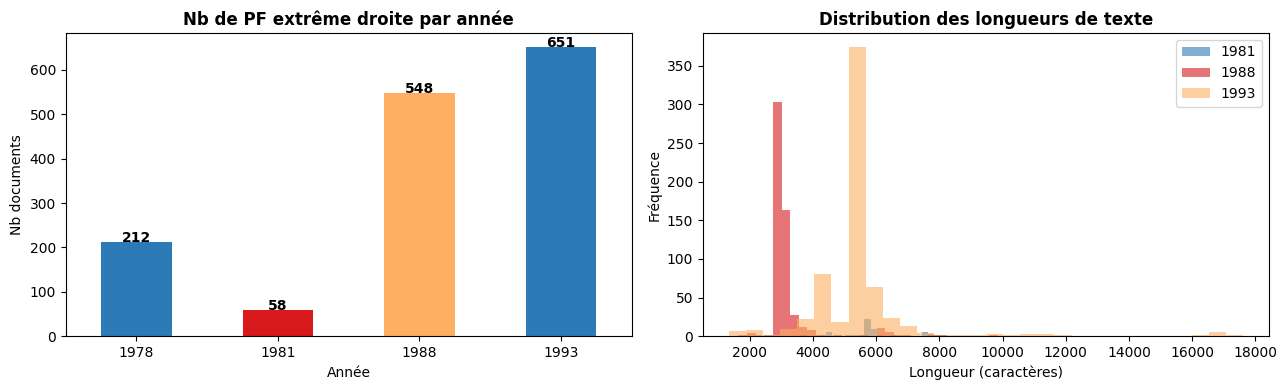

In [8]:
# ── 6. Visualisation ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
colors = ['#2c7bb6', '#d7191c', '#fdae61']

counts = df_ed['year'].value_counts().sort_index()
counts.plot(kind='bar', ax=axes[0], color=colors)
axes[0].set_title('Nb de PF extrême droite par année', fontweight='bold')
axes[0].set_xlabel('Année') ; axes[0].set_ylabel('Nb documents')
axes[0].tick_params(axis='x', rotation=0)
for i, v in enumerate(counts):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

for year, color in zip([1981, 1988, 1993], colors):
    sub = df_ed[df_ed['year'] == year]['text_length']
    if len(sub) > 0:
        axes[1].hist(sub, bins=30, alpha=0.6, label=str(year), color=color)
axes[1].set_title('Distribution des longueurs de texte', fontweight='bold')
axes[1].set_xlabel('Longueur (caractères)') ; axes[1].set_ylabel('Fréquence')
axes[1].legend()

plt.tight_layout()
plt.savefig('corpus_overview.png', dpi=150, bbox_inches='tight')
plt.show()

In [9]:
# ── 7. Aperçu qualitatif ──────────────────────────────────────────────────────
print("\n" + "="*65)
print("APERÇU — 3 exemples de PF extrême droite identifiées")
print("="*65)
for _, row in df_ed.sample(n=min(3, len(df_ed)), random_state=42).iterrows():
    print(f"\n[{row['year']} | {row.get('titulaire-prenom','')} "
          f"{row.get('titulaire-nom','')} | Parti : {row['titulaire-liste']}]")
    print(textwrap.fill(row['text'][:400], width=88))


APERÇU — 3 exemples de PF extrême droite identifiées

[1993 | Roger Douce | Parti : non mentionné]
Sciences Po / fonds CEVIPOF ÉLECTIONS LÉGISLATIVES DE MARS 1993 - 6ème CIRCONSCRIPTION
DE L'ESSONNE FRONT NATIONAL LES FRANÇAIS D'ABORD ! LE PEN avec Jean-Marie VOTEZ ROGER
DOUCE Ingénieur informaticien Responsable Front National de la 6ème circonscription de
l'Essonne Candidat aux Elections cantonales de Mars 1992 SUPPLÉANT : JEAN-LOUIS SERVONAT
Marié, 2 enfants Gestionnaire Chers compatriotes, C

[1978 | Jean-M Merce | Parti : non mentionné]
Sciences Po / fonds CEVIPOF ELECTIONS LEGISLATIVES DU 12 MARS 1978 DEPARTEMENT DE
L'YONNE - 1 ère CIRCONSCRIPTION CANDIDATURE DU FRONT NATIONAL (Président Jean-Marie LE
PEN) soutenu par le Centre Démocrate et Républicain Jean .M MERCE Candidat Suppléant
Alain MEZIERE Françaises, Français, Les partis politiques, qu'ils soient de la majorité
ou de l'opposition de gauche vous mentent. Ils monopolisen

[1993 | Robert Martig | Parti : non mentionné]
Sci

---
## Étape 3 — Prétraitement des textes

Avant de pouvoir faire le _topic modeling_, il faut :

**1. Nettoyager les textes** : les textes numérisées contiennent des éléments qui pourraient perturber l'analyse, on nettoie les textes par précaution. C'est également l'occasion de supprimer les _stop words_.

**2. Lemmatisation avec spaCy** : pour revenir à la racine des mots et avoir des analyses thématiques.

In [19]:
import spacy

# ── 1. Nettoyage des textes ──────────────────────────────────────────────────────
def clean_ocr(text):
    """
    Nettoyage des artefacts spécifiques aux professions de foi Archelec numérisées.
    """
    # 1. Suppression des éléments  "Sciences Po / CEVIPOF"
    text = re.sub(r'sciences\s*po\s*/\s*fonds\s*cevipof', ' ', text, flags=re.I)
    text = re.sub(r'sciences\s*po', ' ', text, flags=re.I)
    text = re.sub(r'fonds\s*cevipof', ' ', text, flags=re.I)

    # 2. Suppression des symboles de cases à cocher
    text = re.sub(r'[☐□▢▪▫◻◼■●]', ' ', text)

    # 3. Suppressions des lignes de séparation graphique
    text = re.sub(r'[-=_*·]{3,}', ' ', text)

    # 4. Suppression des mentions d'imprimerie en fin de ligne
    text = re.sub(r'\bIMP[_\s][\w\s\.]+', ' ', text, flags=re.I)
    text = re.sub(r'\bIMPRIME[RIE\s]+[\w\s\.]+', ' ', text, flags=re.I)
    text = re.sub(r'\bPAPIER\s+R[EÉ]CUP[EÉ]R[EÉ][\w\s]+', ' ', text, flags=re.I)

    # 5. Suppression des numéros de page isolés
    text = re.sub(r'^\s*\d{1,2}\s*$', '', text, flags=re.M)

    # 6. Suppression des caractères non imprimables (sauf newline)
    text = ''.join(c for c in text
                   if unicodedata.category(c)[0] != 'C' or c == '\n')

    # 7. Suppression des espaces multiples
    text = re.sub(r'\s+', ' ', text)
    return text.strip()


# Stopwords 
# On prend les stop words fournis par spaCy directement
# On commence par charger le modèle
nlp = spacy.load('fr_core_news_sm', disable=['parser', 'ner'])

# on récupère les stop words
SW_SPACY = set(nlp.Defaults.stop_words)

# On ajoute quelques Stopwords supplémentaires : termes présents dans TOUTES les PF
# quelle que soit l'orientation politique → non informatifs pour le topic modeling
SW_PF = {
    # Formules électorales génériques
    'voter', 'votez', 'vote', 'suffrage', 'suffrages', 'bulletin',
    # Termes institutionnels présents dans toutes les PF
    'candidat', 'candidature', 'circonscription', 'département',
    'député', 'suppléant', 'suppléante', 'assemblée', 'parlement',
    'élection', 'électeur', 'électeurs', 'électrice', 'électrices',
    'premier', 'second', 'tour', 'liste', 'programme',
    'cher', 'chère', 'monsieur', 'madame', 'citoyen', 'citoyens',
    # Termes géographiques génériques
    'france', 'français', 'française',
    # Verbes très génériques dans les PF
    'défendre', 'proposer', 'vouloir', 'permettre', 'assurer',
}

df = pd.read_csv("data/stopwords.csv")

SW_CSV = set(df.iloc[:, 0].astype(str).str.strip().str.lower())

# on créer une liste avec l'ensemble des stop words.
ALL_SW = SW_SPACY | SW_PF | SW_CSV

# ── 2. Lématisation des textes ──────────────────────────────────────────────────────
def lemmatize(text, nlp, stopwords):
    """
    Lemmatise le texte et filtre les stopwords, la ponctuation,
    les chiffres et les tokens trop courts.
    """
    doc = nlp(text[:100_000])
    return ' '.join(
        tok.lemma_.lower()
        for tok in doc
        if tok.is_alpha
        and not tok.is_stop
        and not tok.is_punct
        and not tok.is_space
        and len(tok.lemma_) >= 3
        and tok.lemma_.lower() not in stopwords
    )


# ── Application ───────────────────────────────────────────────────────────────
df_ed['text_clean'] = df_ed['text'].apply(clean_ocr)

print(f"Lemmatisation de {len(df_ed)} documents...")
df_ed['text_lemmatized'] = [
    lemmatize(t, nlp, ALL_SW) for t in df_ed['text_clean']
]


# On affiche un exemple de transformation
row = df_ed.iloc[0]
print(f"\n--- Exemple ({row['filename']}) ---")
print("ORIGINAL :")
print(textwrap.fill(row['text'][:400], 90))
print("\nAPRÈS NETTOYAGE + LEMMATISATION :")
print(textwrap.fill(row['text_lemmatized'][:400], 90))

Lemmatisation de 1469 documents...

--- Exemple (EL102_L_1978_03_003_04_1_PF_02.txt) ---
ORIGINAL :
Sciences Po / fonds CEVIPOF ELECTIONS LEGISLATIVES DES 12 ET 19 MARS 1978 département de
l'Allier - 4e circonscription Candidature : FRONT NATIONAL Président : Jean-Marie LE PEN
et Centre Démocrate et Républicain Candidate : Brigitte ANDRÉ 26 ans - Mère de famille Un
enfant Suppléante : Paulette GUERRA 50 ans - Veuve - Secrétaire de direction Françaises,
Français, Les partis politiques, qu'ils soi

APRÈS NETTOYAGE + LEMMATISATION :
election legislatives allier front national président pen centre démocrate républicain
candidate brigitte andré mère famille enfant paulette guerra veuve secrétaire direction
françaises parti politique opposition gauche mentir monopoliser télévision radio prétendre
obliger choisir front national affirmer choisir libremer confronter aspiration engagement
établir véritable dialogue méthode original


---
## Étape 4 — LDA (Latent Dirichlet Allocation)

On utilise `CountVectorizer` (comptage brut) avec des **bigrammes** pour capturer les expressions composées caractéristiques de l'extrème droite (i.e. `préférence nationale`, `chômage immigrés`, `insécurité quotidienne`...).

In [20]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation

N_FEATURES = 2000   # taille du vocabulaire
N_TOPICS   = 8      # nombre de sujets

# ── Vectorisation CountVectorizer ─────────────────────────────────────────────
# Choix des paramètres
# ngram_range=(1,2) : unigrammes ET bigrammes
# min_df=2          : un terme doit apparaître dans ≥2 documents (filtre le bruit OCR)
# max_df=0.9        : ignorer les termes dans >90% des docs (trop généraux)
tf_vectorizer = CountVectorizer(
    max_features=N_FEATURES,
    stop_words=list(ALL_SW),
    min_df=2, max_df=0.9,
    ngram_range=(1, 2)
)
tf_matrix = tf_vectorizer.fit_transform(df_ed['text_lemmatized'])

# ── Entraînement LDA ──────────────────────────────────────────────────────────
# On entraine le modèle sur nos données
lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    max_iter=20,
    learning_method='batch',
    random_state=42,
    n_jobs=-1
)
lda.fit(tf_matrix)

# On affiche les mots les plus importants pour chaque sujet
feat_names = tf_vectorizer.get_feature_names_out()

for i, topic in enumerate(lda.components_):
    top = [feat_names[j] for j in np.argsort(-topic)[:15]]
    print(f"\nTopic {i:02d} : {', '.join(top)}")

c:\Users\jonas\OneDrive - GENES\Documents\0 ENSAE\3A\S2\ML_for_NLP\NLP_project\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['po', 'quelqu', 'sciences'] not in stop_words.
  warnings.warn(



Topic 00 : public, liberté, enseignement, moyen, véritable, travail, justice, inflation, production, qualité, justice social, rigoureux, catastrophique, établir, gauche

Topic 01 : impôt, rétablir, retraite, sauver, responsable, chômage, nationalité, insécurité, voix, carte, revenu, créer, affaire, sécurité, code nationalité

Topic 02 : républicain, juge, décadence, actuel, tixier, national président, artisanal, cour, long, profession, scientifique, coupe, père famille, suite, mentir

Topic 03 : avenir, vivre, populaire, confiance, conviction, avenir front, suppression, république, mère, droit, mère famille, françois, agriculteur, lepen, confirmer

Topic 04 : impôt, politique, priorité, enfant, emploi, travail, gauche, droit, étranger, chômage, suppression, réduction, taxe, insécurité, code

Topic 05 : rétablir, voix, impôt, retraite, supprimer, carte, sauver, chômage, organiser, responsable, emploi, renouvelable, créer, séjour renouvelable, séjour

Topic 06 : politique, travailleur, 

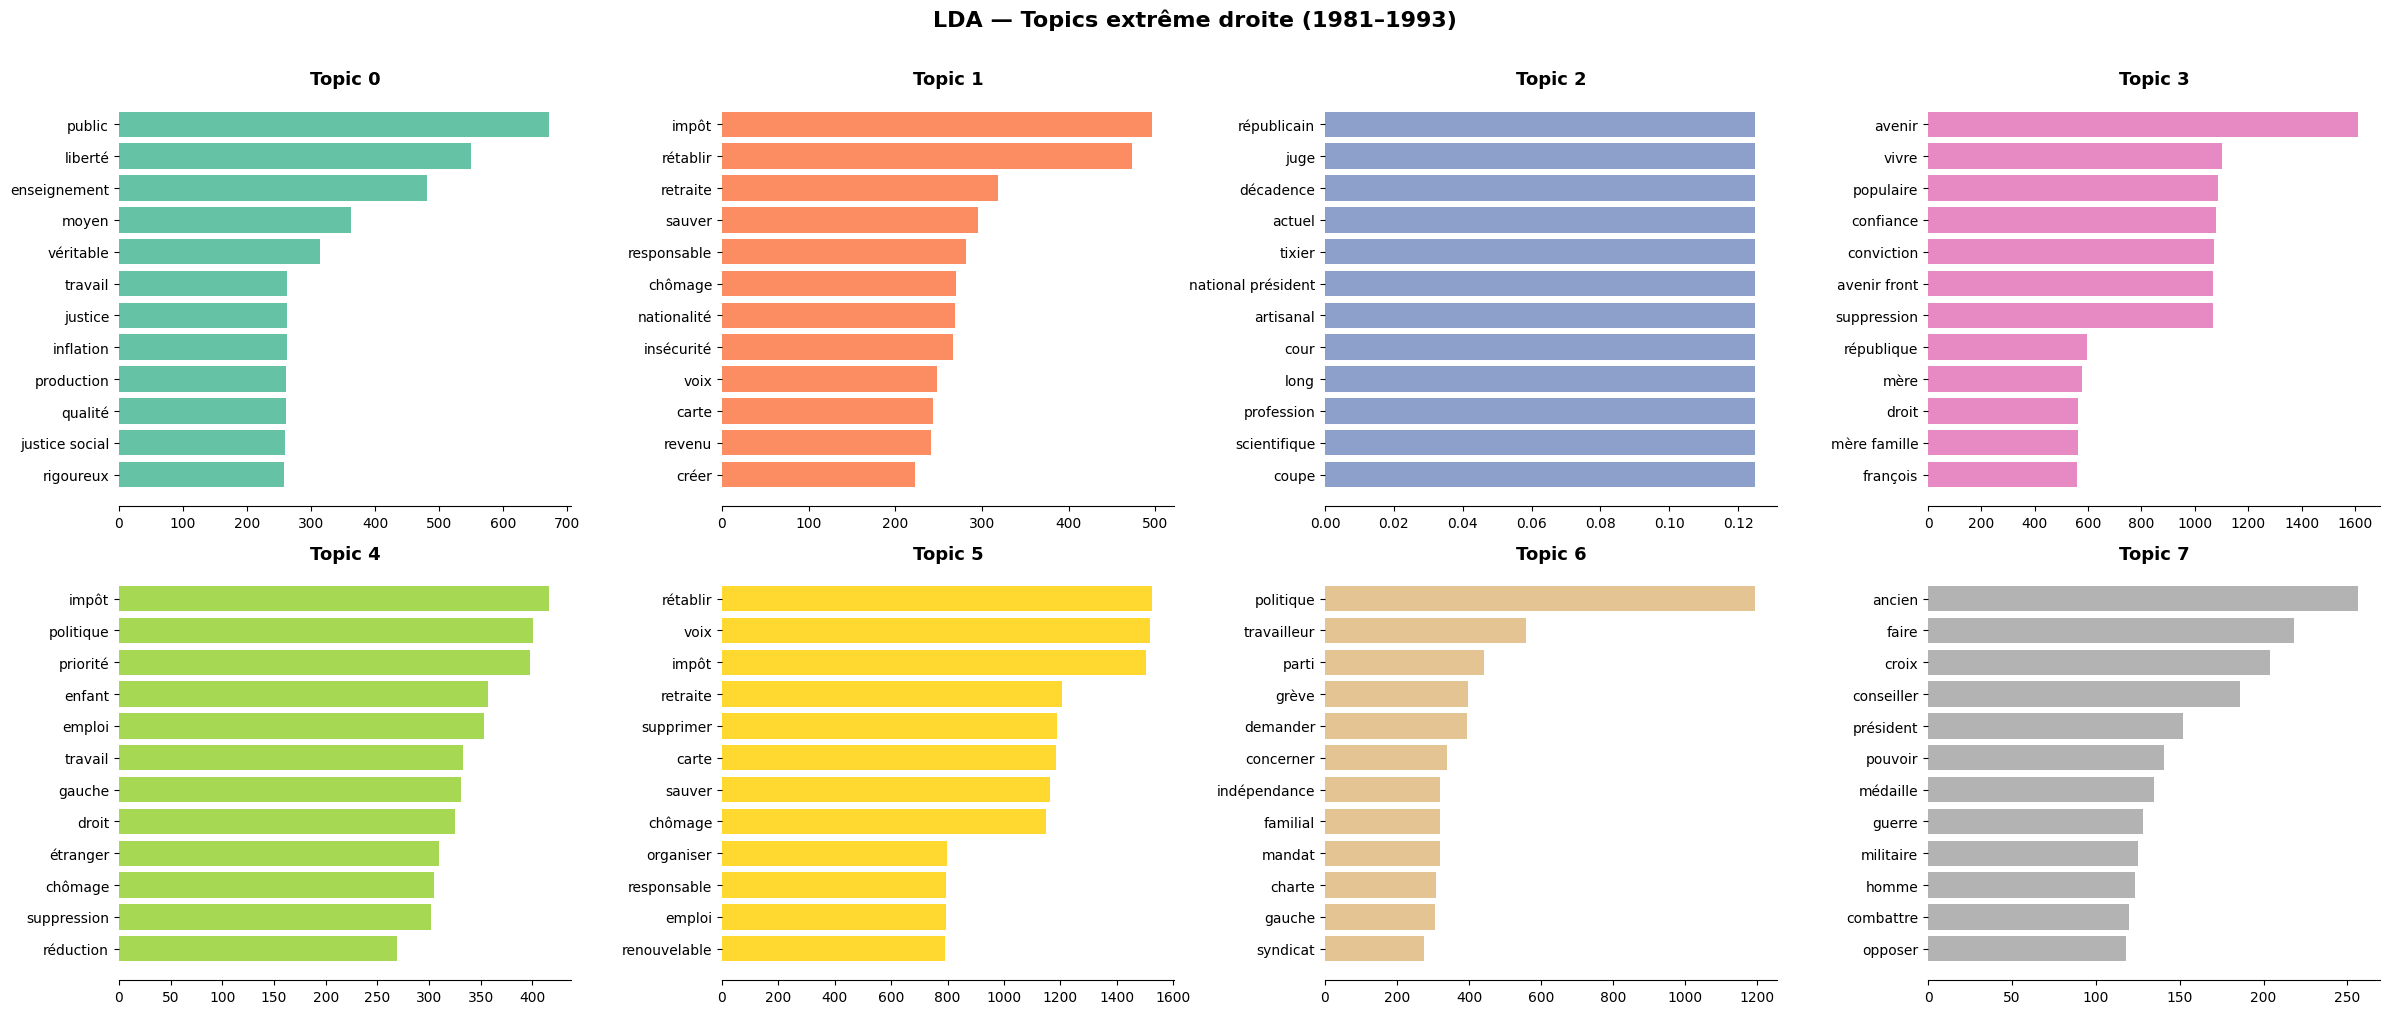

In [21]:
def plot_top_words(model, vectorizer, n_top, title, nb_cols=4):
    """Graphique en barres horizontales — top mots par topic."""
    fn   = vectorizer.get_feature_names_out()
    n_t  = len(model.components_)
    cols = min(nb_cols, n_t)
    rows = (n_t + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(cols*6, rows*5))
    axes = axes.flatten() if n_t > 1 else [axes]
    pal  = plt.cm.Set2(np.linspace(0, 1, n_t))
    for idx, topic in enumerate(model.components_):
        top_i = topic.argsort()[-n_top:]
        ax    = axes[idx]
        ax.barh(fn[top_i], topic[top_i], color=pal[idx])
        ax.set_title(f"Topic {idx}", fontsize=13, fontweight='bold')
        ax.tick_params(labelsize=10)
        for sp in ['top','right','left']: ax.spines[sp].set_visible(False)
    for i in range(n_t, len(axes)): axes[i].set_visible(False)
    fig.suptitle(title, fontsize=16, fontweight='bold', y=1.01)
    plt.tight_layout() ; plt.show()


plot_top_words(lda, tf_vectorizer, 12,
               "LDA — Topics extrême droite (1981–1993)")

In [22]:
import pyLDAvis, pyLDAvis.lda_model
pyLDAvis.enable_notebook()

# Visualisation interactive :
# • Taille des bulles = importance du topic dans le corpus
# • Distance entre bulles = similarité (topics proches = similaires)
pyLDAvis.lda_model.prepare(lda, tf_matrix, tf_vectorizer)

PreparedData(topic_coordinates=              x         y  topics  cluster       Freq
topic                                                
5     -0.331616  0.020458       1        1  35.935409
3      0.188876  0.293842       2        1  24.291401
6      0.177169 -0.204976       3        1  11.953480
0      0.138412 -0.211475       4        1  11.557933
1     -0.307302  0.023001       5        1   8.041393
4     -0.016018  0.001369       6        1   6.712044
7      0.129010  0.207278       7        1   1.477257
2      0.021470 -0.129498       8        1   0.031084, topic_info=            Term         Freq        Total Category  logprob  loglift
637        faire  1517.000000  1517.000000  Default  30.0000  30.0000
969       lutter  1589.000000  1589.000000  Default  29.0000  29.0000
828        impôt  2531.000000  2531.000000  Default  28.0000  28.0000
1257   politique  2251.000000  2251.000000  Default  27.0000  27.0000
341   conseiller   803.000000   803.000000  Default  26.0000  26.0000
...          ...          ...          ...      ...      ...      ...
1239       place     0.091521   216.987433   Topic8  -7.6009   0.3052
688        fonds     0.091521   177.404019   Topic8  -7.6009   0.5066
1915        voir     0.091521    96.020213   Topic8  -7.6009   1.1205
1877   urbanisme     0.091521    96.575089   Topic8  -7.6009   1.1147
83      alliance     0.091521   134.527407   Topic8  -7.6009   0.7833

[520 rows x 6 columns], token_table=      Topic      Freq                    Term
term                                         
7         3  0.989709  abrogation possibilité
13        3  0.996539                  absolu
15        3  0.989709           absolu votant
16        3  0.991360                    abus
17        3  0.989709         abus gaspillage
...     ...       ...                     ...
1988      3  0.070009                étranger
1988      4  0.123392                étranger
1988      5  0.082261                étranger
1988      6  0.268661                étranger
1993      2  0.991677          éventuel lepen

[1127 rows x 3 columns], R=30, lambda_step=0.01, plot_opts={'xlab': 'PC1', 'ylab': 'PC2'}, topic_order=[6, 4, 7, 1, 2, 5, 8, 3])

---
## Étape 5 — NMF (Non-negative Matrix Factorization)


In [23]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF
import numpy as np

# ── Vectorisation TF-IDF ──────────────────────────────────────────────────────
tfidf_vectorizer = TfidfVectorizer(
    max_features=N_FEATURES,
    stop_words=list(ALL_SW),
    min_df=2,
    max_df=0.9,
    ngram_range=(1, 2),
    sublinear_tf=True
)

tfidf_matrix = tfidf_vectorizer.fit_transform(df_ed['text_lemmatized'])

# récupérer les mots
fn_tfidf = tfidf_vectorizer.get_feature_names_out()

# ── Entraînement NMF ──────────────────────────────────────────────────────────
nmf = NMF(
    n_components=N_TOPICS,
    init='nndsvda',
    random_state=42,
    max_iter=400
)

W = nmf.fit_transform(tfidf_matrix)

# ── Top mots par topic ────────────────────────────────────────────────────────
for i, topic in enumerate(nmf.components_):

    top_idx = np.argsort(topic)[::-1][:20]

    top_words = [fn_tfidf[j] for j in top_idx]

    print(f"\nTopic {i:02d} : {', '.join(top_words)}")

c:\Users\jonas\OneDrive - GENES\Documents\0 ENSAE\3A\S2\ML_for_NLP\NLP_project\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['po', 'quelqu', 'sciences'] not in stop_words.
  warnings.warn(



Topic 00 : avenir front, conviction, vivre, confiance, suppression, avenir, lepen, confirmer, vivre vivre, vivre république, redressement, absent élu, quota maintien, enseignement suppression, suppression quota, terre lutte, presque absent, centriste, prononcer clairement, payent

Topic 01 : carte, rétablir, sauver, retraite, impôt, supprimer, séjour renouvelable, renouvelable, carte séjour, sauver agriculture, séjour, écologiste, proteger, famille françaises, traité, immigration chômage, nationalité, affaire, chômage insécurité, agriculture

Topic 02 : inflation, catastrophique, rigoureux, production, établir, justice social, établir véritable, activité, defendre, qualité, véritable, accord, profession, patrie, public, élire, survivre, développer, penser, enseignement

Topic 03 : demander, charte, concerner, indépendance, charte immigration, travailleur immigré, montrez, interdiction, principe, afrique, instauration, commune, occident, grève, familial, parti, syndicat, vie, forcez, p

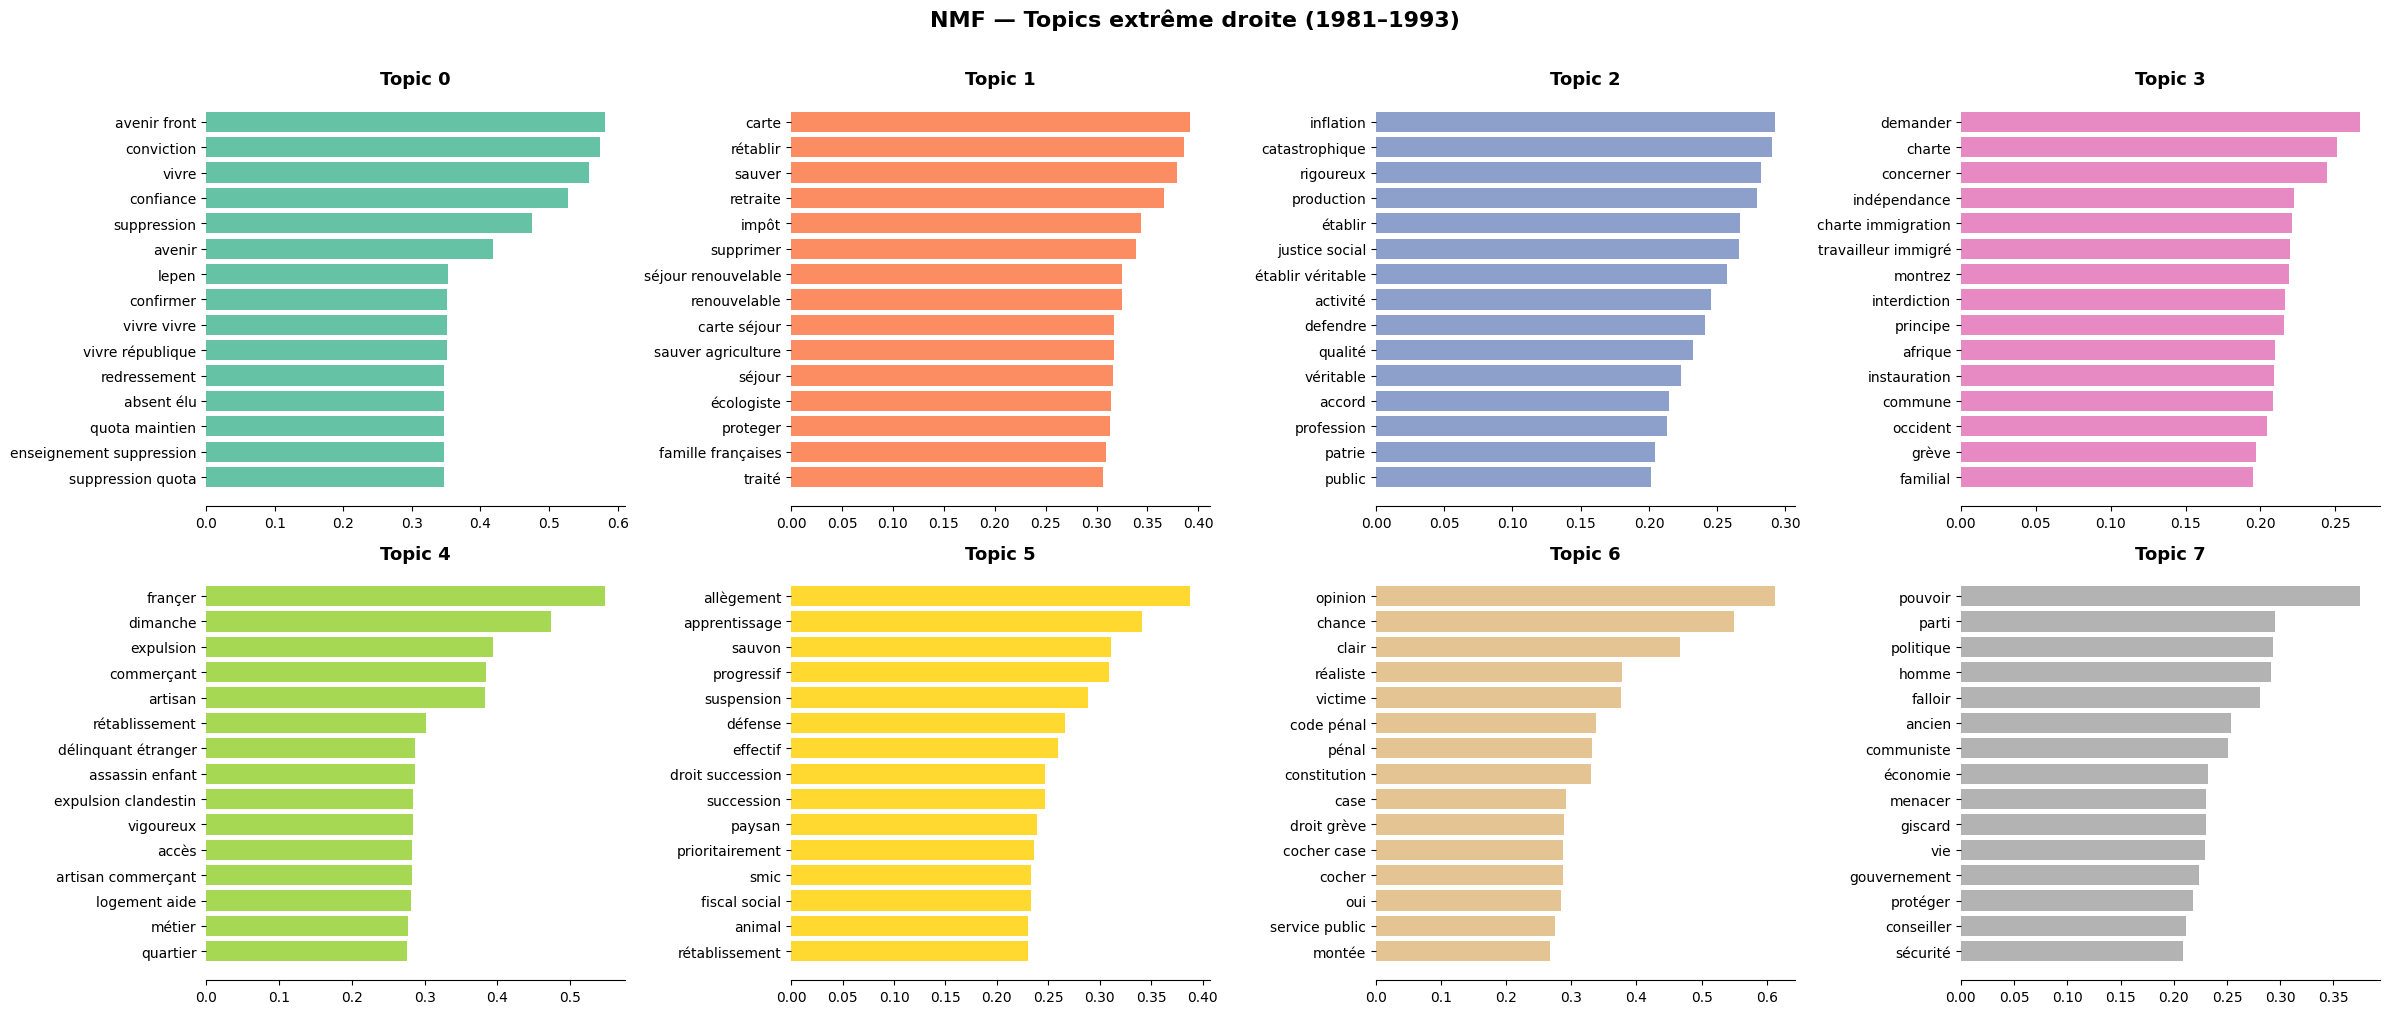

In [24]:
plot_top_words(nmf, tfidf_vectorizer, 15,
               "NMF — Topics extrême droite (1981–1993)")

In [29]:
# ── Étiquetage manuel des topics pour les visualisations suivantes ──────────────────────────────────────────────
topic_labels = {
    0: 'Valeurs et peuple',
    1: 'Encadrer les migration',
    2: 'Fiscalité',
    3: 'Anti-immigration',
    4: 'Coupables et victimes',
    5: 'Mesures politiques',
    6: 'Opinion',
    7: 'Politique',
}

---
## Étape 6 — Analyse temporelle

La matrice W donne le poids de chaque topic dans chaque document. En agrégeant par année, on peut observer si certains thèmes montent, descendent ou disparaissent.

In [30]:
# ── Normalisation de W ────────────────────────────────────────────────────────
# On normalise chaque ligne pour avoir des proportions (somme = 1 par document)
W_norm = W / W.sum(axis=1, keepdims=True)

# Ajouter au DataFrame
for t in range(N_TOPICS):
    df_ed[f't{t}'] = W_norm[:, t]
df_ed['dominant_topic']       = np.argmax(W_norm, axis=1)
df_ed['dominant_score']       = np.max(W_norm, axis=1)
df_ed['dominant_label']       = df_ed['dominant_topic'].map(topic_labels)

# ── Poids moyen par topic et par année ────────────────────────────────────────
topic_cols = [f't{t}' for t in range(N_TOPICS)]
by_year    = df_ed.groupby('year')[topic_cols].mean()
by_year.columns = [f"T{t}: {topic_labels[t]}" for t in range(N_TOPICS)]

print("Importance moyenne des topics par année :")
print(by_year.round(3).to_string())

Importance moyenne des topics par année :
      T0: Valeurs et peuple  T1: Encadrer les migration  T2: Fiscalité  T3: Anti-immigration  T4: Coupables et victimes  T5: Mesures politiques  T6: Opinion  T7: Politique
year                                                                                                                                                                       
1978                  0.000                       0.000          0.437                 0.367                      0.006                   0.003        0.143          0.043
1981                  0.004                       0.000          0.422                 0.043                      0.003                   0.002        0.031          0.496
1988                  0.918                       0.001          0.001                 0.003                      0.013                   0.005        0.009          0.050
1993                  0.002                       0.640          0.001                 0.003      

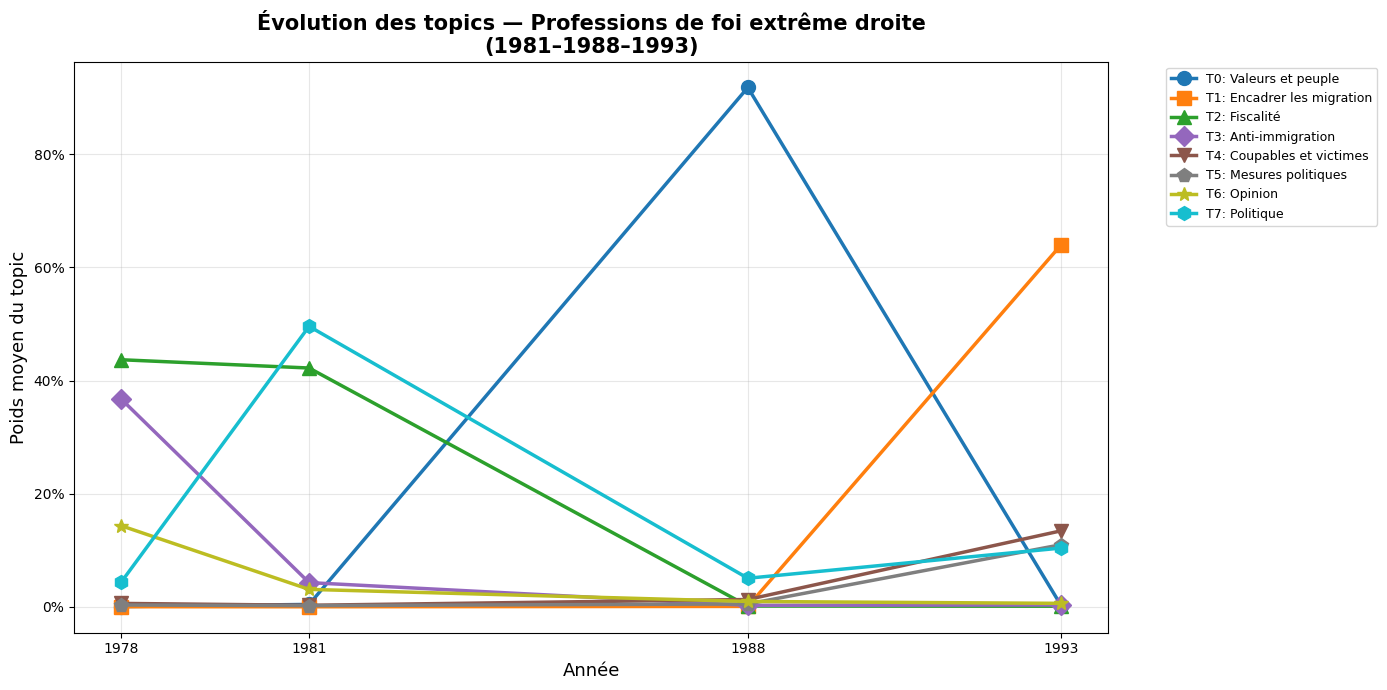

In [31]:
# ── Graphique 1 : évolution par topic (courbes) ───────────────────────────────
fig, ax = plt.subplots(figsize=(14, 7))
pal     = plt.cm.tab10(np.linspace(0, 1, N_TOPICS))
mkrs    = ['o','s','^','D','v','p','*','h']
years_avail = sorted(by_year.index.tolist())

for i, col in enumerate(by_year.columns):
    ax.plot(years_avail, by_year.loc[years_avail, col],
            marker=mkrs[i % len(mkrs)], lw=2.5, ms=10,
            label=col, color=pal[i])

ax.set_xticks(years_avail)
ax.set_xlabel('Année', fontsize=13)
ax.set_ylabel('Poids moyen du topic', fontsize=13)
ax.set_title('Évolution des topics — Professions de foi extrême droite\n(1981–1988–1993)',
             fontsize=15, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('topic_evolution.png', dpi=150, bbox_inches='tight')
plt.show()

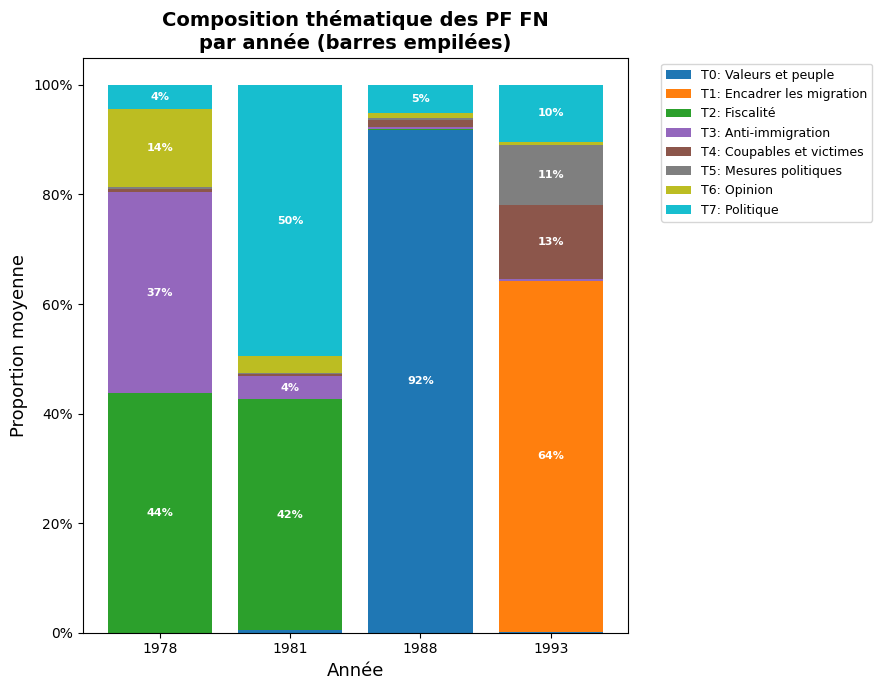

In [32]:
# ── Graphique 2 : barres empilées — composition thématique par année ──────────
fig, ax = plt.subplots(figsize=(9, 7))
bottom  = np.zeros(len(years_avail))
xlabels = [str(y) for y in years_avail]

for i, col in enumerate(by_year.columns):
    vals = by_year.loc[years_avail, col].values
    ax.bar(xlabels, vals, bottom=bottom, label=col, color=pal[i])
    # Afficher le % si la part est suffisamment grande
    for xi, (v, b) in enumerate(zip(vals, bottom)):
        if v > 0.04:
            ax.text(xi, b + v/2, f'{v:.0%}', ha='center', va='center',
                    fontsize=8, color='white', fontweight='bold')
    bottom += vals

ax.set_xlabel('Année', fontsize=13)
ax.set_ylabel('Proportion moyenne', fontsize=13)
ax.set_title('Composition thématique des PF FN\npar année (barres empilées)',
             fontsize=14, fontweight='bold')
ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
ax.set_ylim(0, 1.05)
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
plt.tight_layout()
plt.savefig('topic_stacked.png', dpi=150, bbox_inches='tight')
plt.show()

---
## Étape 7 — NMF séparé par année

Pour détecter les thèmes **spécifiques à chaque élection**, on entraîne un NMF indépendant par année. Cela permet de voir des topics émergents en 1993 qui n'auraient pas de poids suffisant dans le modèle global.

In [34]:
N_T_YEAR = 5   # moins de topics car sous-corpus plus petits

for year in YEARS:
    sub = df_ed[df_ed['year'] == year]
    n   = len(sub)
    print(f"\n{'─'*60}")
    print(f" {year} — {n} professions de foi")
    print(f"{'─'*60}")

    if n < 10:
        # Corpus trop petit → afficher simplement les mots les plus fréquents
        print(f"  Corpus trop petit pour NMF ({n} docs).")
        print("  Mots les plus fréquents (hors stopwords) :")
        words = [w for t in sub['text_lemmatized'] for w in t.split()
                 if w not in ALL_SW and len(w) >= 4]
        top20 = [w for w, _ in Counter(words).most_common(20)]
        print(f"  {', '.join(top20)}")
        continue

    vec = TfidfVectorizer(
        max_features=800, stop_words=list(ALL_SW),
        min_df=2, max_df=0.95, ngram_range=(1, 2)
    )
    mat = vec.fit_transform(sub['text_lemmatized'])

    nmf_y = NMF(n_components=N_T_YEAR, init='nndsvda', random_state=42)
    nmf_y.fit(mat)

    fn_y = vec.get_feature_names_out()
    for t_idx, topic in enumerate(nmf_y.components_):
        top = [fn_y[j] for j in np.argsort(-topic)[:12]]
        print(f"  Topic {t_idx} : {', '.join(top)}")


────────────────────────────────────────────────────────────
 1978 — 212 professions de foi
────────────────────────────────────────────────────────────
  Topic 0 : front national, front, enseignement, moyen, retablir, catastrophique, defendre, rigoureux, activité, penser, inflation, production
  Topic 1 : travailleur, demander, mandat, charte, concerner, indépendance, familial, charte immigration, montrez, commune, référendum, travailleur immigré
  Topic 2 : oui, opinion, chance, clair, front, front national, code, code pénal, pénal, constitution, exprimer, justice
  Topic 3 : front, front national, travailleur, allocation, grand, salaire, pouvoir, société, parti, allocation familial, prix, familial
  Topic 4 : économique, société, enseignement, crise, vie, familial, ordre, enfant, immigration, justice, arrêter, armée

────────────────────────────────────────────────────────────
 1981 — 58 professions de foi
────────────────────────────────────────────────────────────


c:\Users\jonas\OneDrive - GENES\Documents\0 ENSAE\3A\S2\ML_for_NLP\NLP_project\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['po', 'quelqu', 'sciences'] not in stop_words.
  warnings.warn(
c:\Users\jonas\OneDrive - GENES\Documents\0 ENSAE\3A\S2\ML_for_NLP\NLP_project\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['po', 'quelqu', 'sciences'] not in stop_words.
  warnings.warn(


  Topic 0 : front, public, social, populaire, économie, front populaire, patrie, élire, développer, famille, liberté patrie, battre
  Topic 1 : savoir, gauche, opposer, pouvoir, réclamer, combattre, lutter, idée, faire, information, campagne, volonté
  Topic 2 : appel, réaliser, rassemblement national, chirac, national appel, objectif, ignorer, inverser, lecanuet, courant, électoral, année
  Topic 3 : françois, parti, union, union parti, emploi, montrez, françois mitterrand, moyen, marxiste, public, république, résultat
  Topic 4 : front, front national, patrie, paris, marier enfant, militaire, ancien, marier, pouvoir, rassemblement, enfant, droit

────────────────────────────────────────────────────────────
 1988 — 548 professions de foi
────────────────────────────────────────────────────────────
  Topic 0 : paris, clergerie paris, général clergerie, clergerie, rue général, général, écrir rue, rue, nationale, écrir, populaire nationale, entent
  Topic 1 : seine, ihre, vertrauen, dere

c:\Users\jonas\OneDrive - GENES\Documents\0 ENSAE\3A\S2\ML_for_NLP\NLP_project\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['po', 'quelqu', 'sciences'] not in stop_words.
  warnings.warn(
c:\Users\jonas\OneDrive - GENES\Documents\0 ENSAE\3A\S2\ML_for_NLP\NLP_project\.venv\Lib\site-packages\sklearn\feature_extraction\text.py:411: UserWarning: Your stop_words may be inconsistent with your preprocessing. Tokenizing the stop words generated tokens ['po', 'quelqu', 'sciences'] not in stop_words.
  warnings.warn(


  Topic 0 : rétablir, voix, carte, sauver, supprimer, retraite, immigré, proteger, séjour renouvelable, renouvelable, écologiste, créer
  Topic 1 : françer, dimanche, priorité, confiance, commerçant, drogue, artisan, expulsion, réduction, étranger, pouvoir, suppression
  Topic 2 : suppression, création, progressif, lutte, effectif, allègement, défense, réduction, droit, apprentissage, sauvon, suspension
  Topic 3 : protéger, rétablir, immigré, créer, alléger, sauver, accorder priorité, retraite, économie concurrence, libérer pme, protéger économie, créer revenu
  Topic 4 : ancien, conseiller, socialiste, familial, municipal, droit, pouvoir, conseiller municipal, parti, croix, vie, politique


---
## Étape 8 — BERTopic + Topics Over Time

BERTopic utilise des **embeddings contextuels** (transformers) plutôt que des fréquences de mots. Il peut détecter des similarités sémantiques que LDA/NMF ratent (ex : deux PF qui parlent du même sujet avec des mots différents).

La fonctionnalité **Topics Over Time** calcule directement l'évolution de chaque topic sur la période.

In [35]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
from sklearn.feature_extraction.text import CountVectorizer as CV_bert

docs       = df_ed['text_clean'].tolist()    # texte nettoyé (pas lemmatisé)
timestamps = df_ed['year'].tolist()

# ── 1. Embeddings sémantiques ─────────────────────────────────────────────────
# Modèle multilingue léger — bon compromis vitesse/qualité pour le français
print("Encodage des documents...")
emb_model  = SentenceTransformer('paraphrase-multilingual-MiniLM-L12-v2')
embeddings = emb_model.encode(docs, show_progress_bar=True, batch_size=32)
print(f"Embeddings : {embeddings.shape}")

# ── 2. CountVectorizer pour les labels de topics ──────────────────────────────
vec_bert = CV_bert(stop_words=list(ALL_SW), min_df=2, ngram_range=(1, 2))

# ── 3. BERTopic ───────────────────────────────────────────────────────────────
# min_topic_size : baisser si corpus petit (ex: 5–10)
# nr_topics='auto' : fusionne automatiquement les topics trop similaires
topic_model = BERTopic(
    language='french',
    vectorizer_model=vec_bert,
    min_topic_size=5,
    nr_topics='auto',
    verbose=True
)
topics, probs = topic_model.fit_transform(docs, embeddings)

info = topic_model.get_topic_info()
print(f"\n {len(info)} topics découverts | {topics.count(-1)} outliers (topic -1)")
print(info[info['Topic'] != -1].to_string())

Encodage des documents...


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Batches:   0%|          | 0/46 [00:00<?, ?it/s]

2026-04-24 15:26:44,779 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm


Embeddings : (1469, 384)


2026-04-24 15:26:56,746 - BERTopic - Dimensionality - Completed ✓
2026-04-24 15:26:56,747 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-04-24 15:26:56,793 - BERTopic - Cluster - Completed ✓
2026-04-24 15:26:56,794 - BERTopic - Representation - Extracting topics using c-TF-IDF for topic reduction.
2026-04-24 15:26:57,755 - BERTopic - Representation - Completed ✓
2026-04-24 15:26:57,757 - BERTopic - Topic reduction - Reducing number of topics
2026-04-24 15:26:57,769 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-04-24 15:26:58,722 - BERTopic - Representation - Completed ✓
2026-04-24 15:26:58,726 - BERTopic - Topic reduction - Reduced number of topics from 43 to 8



 8 topics découverts | 123 outliers (topic -1)
   Topic  Count                                            Name                                                                                                  Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         

In [41]:
# ── Topics Over Time ──────────────────────────────────────────────────────────
# Calcule l'importance de chaque topic par période.
# C'est la réponse directe à "y a-t-il une évolution entre 1981, 1988 et 1993 ?"
tot = topic_model.topics_over_time(
    docs=docs, timestamps=timestamps,
    nr_bins=3,            # 3 périodes = une par année
    evolution_tuning=True  # lissage entre périodes
)

top_topics = [t for t in info[info['Topic'] != -1]['Topic'].values[:8]]
fig = topic_model.visualize_topics_over_time(
    tot, topics=top_topics,
    title='Topics BERTopic — PF extrême droite'
)
fig.show()

3it [00:02,  1.49it/s]


In [42]:
# ── Carte 2D des documents ────────────────────────────────────────────────────
# Chaque point = une profession de foi ; documents proches = sémantiquement similaires
topic_model.visualize_documents(
    docs=docs, embeddings=embeddings,
    topics=top_topics,
    hide_annotations=False,
    height=700, width=1100,
    title='Carte sémantique des PF extrème droite'
)

---
## Étape 9 — Synthèse : mots distinctifs par année

Pour compléter l'analyse, on calcule les mots les plus **caractéristiques de chaque année** en traitant chaque année comme un mega-document et en calculant un TF-IDF inter-années. Un score élevé pour 1993 = ce mot est utilisé *surtout* en 1993.

In [40]:
year_mega = {y: ' '.join(df_ed[df_ed['year']==y]['text_lemmatized'].tolist())
             for y in YEARS if (df_ed['year']==y).sum() > 0}

if len(year_mega) >= 2:
    ys  = sorted(year_mega)
    vec = TfidfVectorizer(max_features=400, stop_words=list(ALL_SW), min_df=1)
    mat = vec.fit_transform([year_mega[y] for y in ys])
    fn  = vec.get_feature_names_out()

    print("MOTS LES PLUS DISTINCTIFS PAR ANNÉE")
    print("(TF-IDF inter-années : score élevé = utilisé surtout cette année-là)")
    for i, year in enumerate(ys):
        sc   = mat[i].toarray().flatten()
        top  = [fn[j] for j in np.argsort(-sc)[:25] if sc[j] > 0]
        n_docs = (df_ed['year'] == year).sum()
        print(f"\n{'='*55}")
        print(f" {year}  ({n_docs} PF) :")
        print(f"{'='*55}")
        for k in range(0, len(top), 5):
            print('  ' + '  |  '.join(top[k:k+5]))


MOTS LES PLUS DISTINCTIFS PAR ANNÉE
(TF-IDF inter-années : score élevé = utilisé surtout cette année-là)

 1978  (212 PF) :
  politique  |  national  |  front  |  grève  |  pays
  famille  |  public  |  social  |  travailleur  |  gauche
  liberté  |  immigré  |  parti  |  charte  |  véritable
  bloc  |  immigration  |  travail  |  demander  |  indépendance
  enseignement  |  droit  |  devoir  |  entreprise  |  familial

 1981  (58 PF) :
  liberté  |  national  |  gauche  |  front  |  politique
  public  |  enseignement  |  faire  |  patrie  |  mitterrand
  populaire  |  social  |  économie  |  falloir  |  rassemblement
  communiste  |  famille  |  entreprise  |  pays  |  pouvoir
  peine  |  immigré  |  travail  |  mort  |  justice

 1988  (548 PF) :
  national  |  front  |  avenir  |  conviction  |  vivre
  populaire  |  confiance  |  suppression  |  payent  |  antisocialiste
  fiscalist  |  éventuel  |  confirmer  |  lepen  |  remplaçant
  différence  |  vœu  |  barrage  |  exclusion 